In [ ]:
import pandas as pd

df = pd.read_csv('AirQualityUCI.csv',sep=';')
df.head(3)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502,NaN,NaN


In [ ]:
df.drop(columns=['Unnamed: 15','Unnamed: 16'], inplace=True)
print(df.columns)
df.head(3)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502


In [ ]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [ ]:
df.dtypes

,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),int64
NMHC(GT),int64
C6H6(GT),float64
PT08.S2(NMHC),int64
NOx(GT),int64
PT08.S3(NOx),int64
NO2(GT),int64


In [ ]:
df['Date']=pd.to_datetime(df['Date'],format='%d/%m/%Y')

df['Time']=pd.to_datetime(df['Time'],format='%H.%M.%S')

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df["Hour"] = df["Time"].dt.hour
df["Minute"] = df["Time"].dt.minute
df["Second"] = df["Time"].dt.second

df['CO(GT)']=pd.to_numeric(df['CO(GT)'],errors='coerce')
df['C6H6(GT)']=pd.to_numeric(df['C6H6(GT)'],errors='coerce')
df['AH']=pd.to_numeric(df['AH'],errors='coerce')
df['RH']=pd.to_numeric(df['RH'],errors='coerce')
df['T']=pd.to_numeric(df['T'],errors='coerce')

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Time,datetime64[ns]
CO(GT),float64
PT08.S1(CO),int64
NMHC(GT),int64
C6H6(GT),float64
PT08.S2(NMHC),int64
NOx(GT),int64
PT08.S3(NOx),int64
NO2(GT),int64


In [ ]:
df.isna().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [ ]:
neg200_count = {}

for col in df.columns:
    if df[col].dtype in ['int64', 'float64', 'object']:
        count = (df[col] == -200).sum()
        if count > 0:
            neg200_count[col] = count

for col, count in neg200_count.items():
    print(f"Colonne {col} contient {count} valeurs -200")

Colonne CO(GT) contient 1683 valeurs -200
Colonne PT08.S1(CO) contient 366 valeurs -200
Colonne NMHC(GT) contient 8443 valeurs -200
Colonne C6H6(GT) contient 366 valeurs -200
Colonne PT08.S2(NMHC) contient 366 valeurs -200
Colonne NOx(GT) contient 1639 valeurs -200
Colonne PT08.S3(NOx) contient 366 valeurs -200
Colonne NO2(GT) contient 1642 valeurs -200
Colonne PT08.S4(NO2) contient 366 valeurs -200
Colonne PT08.S5(O3) contient 366 valeurs -200
Colonne T contient 366 valeurs -200
Colonne RH contient 366 valeurs -200
Colonne AH contient 366 valeurs -200


In [ ]:
df = df.drop('NMHC(GT)', axis=1)


In [ ]:
import numpy as np

def trouver_3_avant_apres(col):

    n = len(col)

    for i in range(n):

        # vérifier si NaN
        if np.isnan(col[i]):

            # -------- chercher 3 valeurs avant --------
            avant = []
            j = i - 1

            while j >= 0 and len(avant) < 3:
                if not np.isnan(col[j]):
                    avant.append(col[j])
                j -= 1

            # -------- chercher 3 valeurs après --------
            apres = []
            k = i + 1

            while k < n and len(apres) < 3:
                if not np.isnan(col[k]):
                    apres.append(col[k])
                k += 1

            print("Indice :", i)
            print("3 valeurs avant :", avant)
            print("3 valeurs après :", apres)
            print("------")

In [ ]:
import pandas as pd
import numpy as np

# remplacer -200 par NaN si besoin
df.replace(-200, np.nan, inplace=True)

# exemple sur une colonne
colonne = df["CO(GT)"].values

trouver_3_avant_apres(colonne)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Indice : 2033
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7), np.float64(3.6), np.float64(3.3)]
------
Indice : 2034
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7), np.float64(3.6), np.float64(3.3)]
------
Indice : 2035
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7), np.float64(3.6), np.float64(3.3)]
------
Indice : 2036
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7), np.float64(3.6), np.float64(3.3)]
------
Indice : 2037
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7), np.float64(3.6), np.float64(3.3)]
------
Indice : 2038
3 valeurs avant : [np.float64(0.8), np.float64(2.2), np.float64(1.6)]
3 valeurs après : [np.float64(2.7

In [ ]:
num_missing = (df == -200 ).sum()
print(num_missing[num_missing > 0])

Series([], dtype: int64)


In [ ]:
df.isna().sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642
PT08.S4(NO2),366


In [ ]:
cols_numeriques = df.select_dtypes(include=[np.number]).columns
print(cols_numeriques)

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'],
      dtype='object')


In [ ]:
print(df[cols_numeriques].isna().sum())



CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Year                0
Month               0
Day                 0
Hour                0
Minute              0
Second              0
dtype: int64


In [ ]:
df[cols_numeriques] = df[cols_numeriques].interpolate(method="linear")

In [ ]:
print(df.isna().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Year             0
Month            0
Day              0
Hour             0
Minute           0
Second           0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Date, Time, CO(GT), PT08.S1(CO), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH, Year, Month, Day, Hour, Minute, Second]
Index: []


In [ ]:
#verifie les incohérences
print(df.describe())

                                Date                           Time  \
count                           9357                           9357   
mean   2004-09-21 04:30:05.193972480  1900-01-01 11:29:54.806028032   
min              2004-03-10 00:00:00            1900-01-01 00:00:00   
25%              2004-06-16 00:00:00            1900-01-01 05:00:00   
50%              2004-09-21 00:00:00            1900-01-01 11:00:00   
75%              2004-12-28 00:00:00            1900-01-01 18:00:00   
max              2005-04-04 00:00:00            1900-01-01 23:00:00   
std                              NaN                            NaN   

            CO(GT)  PT08.S1(CO)     C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  \
count  9357.000000  9357.000000  9357.000000    9357.000000  9357.000000   
mean      2.130603  1103.059741    10.179155     942.142620   241.922197   
min       0.100000   647.000000     0.100000     383.000000     2.000000   
25%       1.100000   938.000000     4.500000     736.000

In [ ]:
for col in cols_numeriques:
    if (df[col] < 0).any():
        print("Valeurs négatives dans :", col)

Valeurs négatives dans : T


In [ ]:
#la normalisation
from sklearn.preprocessing import StandardScaler

cols_numeriques = df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
df[cols_numeriques] = scaler.fit_transform(df[cols_numeriques])

In [ ]:
print(df[cols_numeriques].mean())

CO(GT)          -2.429985e-17
PT08.S1(CO)     -2.399610e-16
C6H6(GT)        -6.074962e-17
PT08.S2(NMHC)   -8.504947e-17
NOx(GT)          6.074962e-18
PT08.S3(NOx)    -6.682458e-17
NO2(GT)         -4.859970e-17
PT08.S4(NO2)    -1.214992e-16
PT08.S5(O3)     -9.112443e-18
T               -4.859970e-16
RH              -1.063118e-16
AH               4.859970e-17
Year             1.071137e-13
Month            7.289954e-17
Day             -1.063118e-16
Hour            -3.958217e-17
Minute           0.000000e+00
Second           0.000000e+00
dtype: float64


In [ ]:
print(df[cols_numeriques].std())

CO(GT)           1.000053
PT08.S1(CO)      1.000053
C6H6(GT)         1.000053
PT08.S2(NMHC)    1.000053
NOx(GT)          1.000053
PT08.S3(NOx)     1.000053
NO2(GT)          1.000053
PT08.S4(NO2)     1.000053
PT08.S5(O3)      1.000053
T                1.000053
RH               1.000053
AH               1.000053
Year             1.000053
Month            1.000053
Day              1.000053
Hour             1.000053
Minute           0.000000
Second           0.000000
dtype: float64


In [ ]:
print(df[cols_numeriques].describe())

             CO(GT)   PT08.S1(CO)      C6H6(GT)  PT08.S2(NMHC)       NOx(GT)  \
count  9.357000e+03  9.357000e+03  9.357000e+03   9.357000e+03  9.357000e+03   
mean  -2.429985e-17 -2.399610e-16 -6.074962e-17  -8.504947e-17  6.074962e-18   
std    1.000053e+00  1.000053e+00  1.000053e+00   1.000053e+00  1.000053e+00   
min   -1.418356e+00 -2.090246e+00 -1.343276e+00  -2.087504e+00 -1.174338e+00   
25%   -7.198658e-01 -7.565139e-01 -7.568764e-01  -7.696130e-01 -7.142400e-01   
50%   -2.309227e-01 -1.652716e-01 -2.504401e-01  -1.199528e-01 -3.030883e-01   
75%    5.374163e-01  6.230513e-01  5.225418e-01   6.602795e-01  4.115325e-01   
max    6.823827e+00  4.294253e+00  7.132869e+00   4.748353e+00  6.055079e+00   

       PT08.S3(NOx)       NO2(GT)  PT08.S4(NO2)   PT08.S5(O3)             T  \
count  9.357000e+03  9.357000e+03  9.357000e+03  9.357000e+03  9.357000e+03   
mean  -6.682458e-17 -4.859970e-17 -1.214992e-16 -9.112443e-18 -4.859970e-16   
std    1.000053e+00  1.000053e+00  1.00005

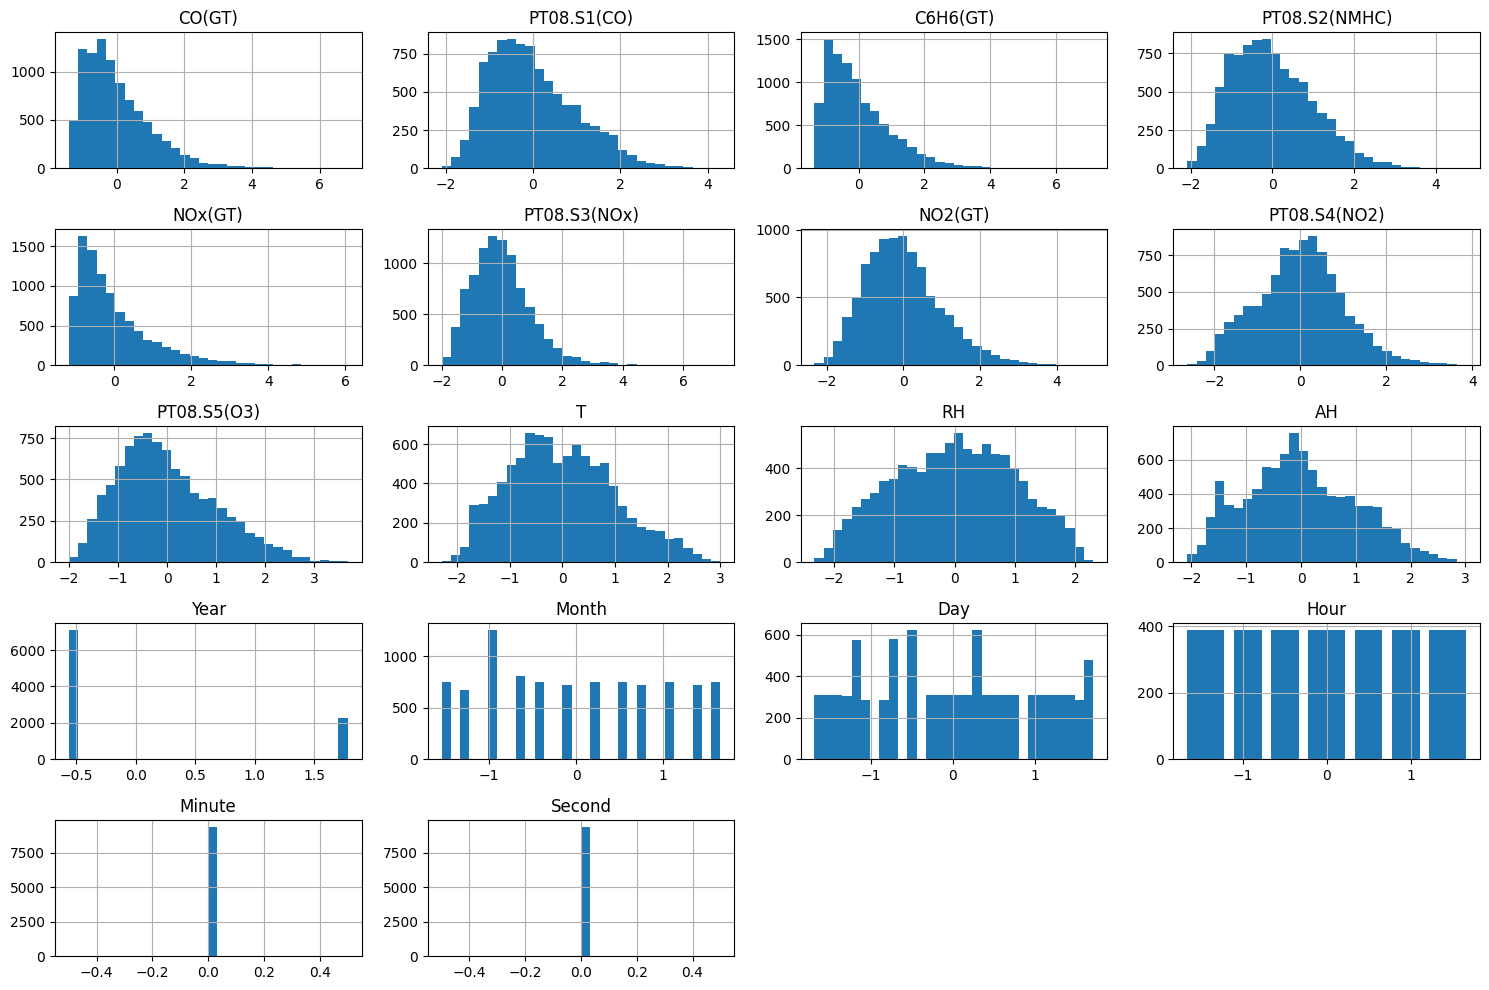

In [ ]:
#Visualiser la distribution des donnes
import matplotlib.pyplot as plt

df[cols_numeriques].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

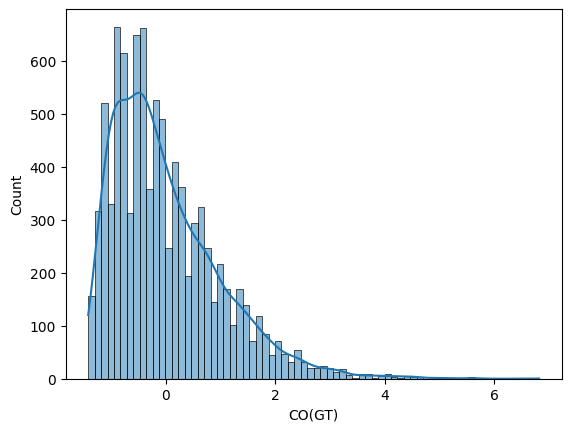

In [ ]:
#Distribution des données normalisées
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["CO(GT)"], kde=True)
plt.show()

In [ ]:
#Vérifier l’asymétrie
print(df[cols_numeriques].skew())

CO(GT)           1.292296
PT08.S1(CO)      0.711458
C6H6(GT)         1.337035
PT08.S2(NMHC)    0.557134
NOx(GT)          1.697908
PT08.S3(NOx)     1.091029
NO2(GT)          0.707574
PT08.S4(NO2)     0.207815
PT08.S5(O3)      0.603006
T                0.325319
RH              -0.043924
AH               0.259390
Year             1.216851
Month            0.116099
Day             -0.022216
Hour             0.000529
Minute           0.000000
Second           0.000000
dtype: float64


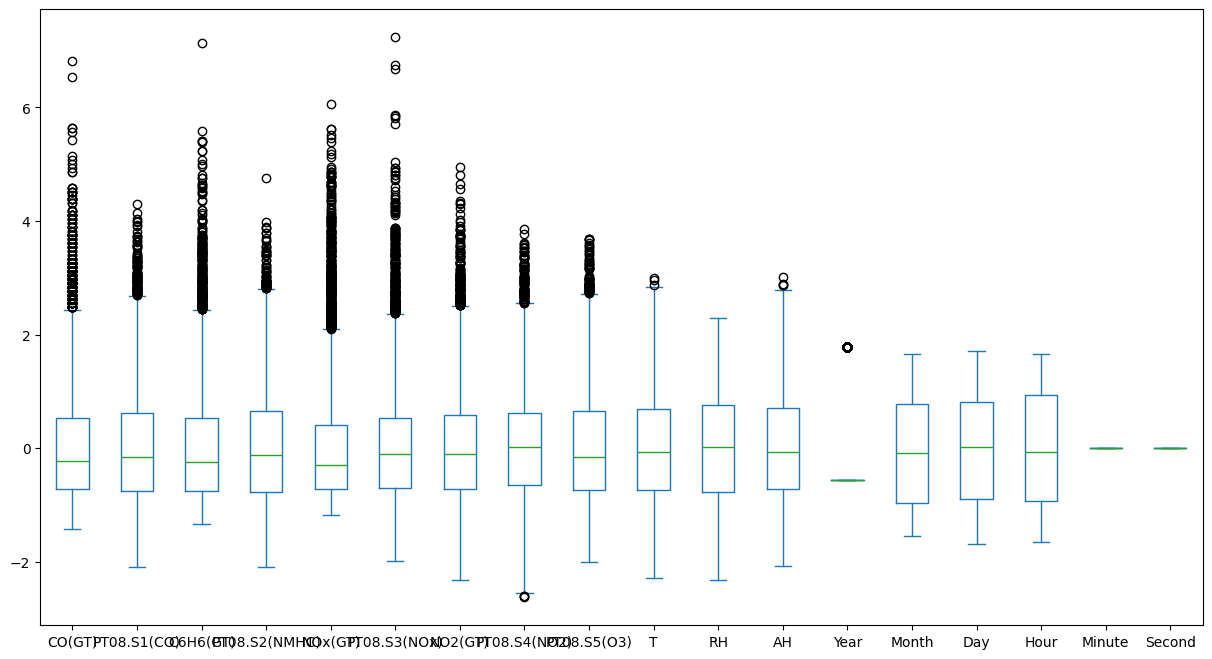

In [ ]:
#vérifier les outliers (Boxplot)
df[cols_numeriques].plot(kind="box", figsize=(15,8))
plt.show()

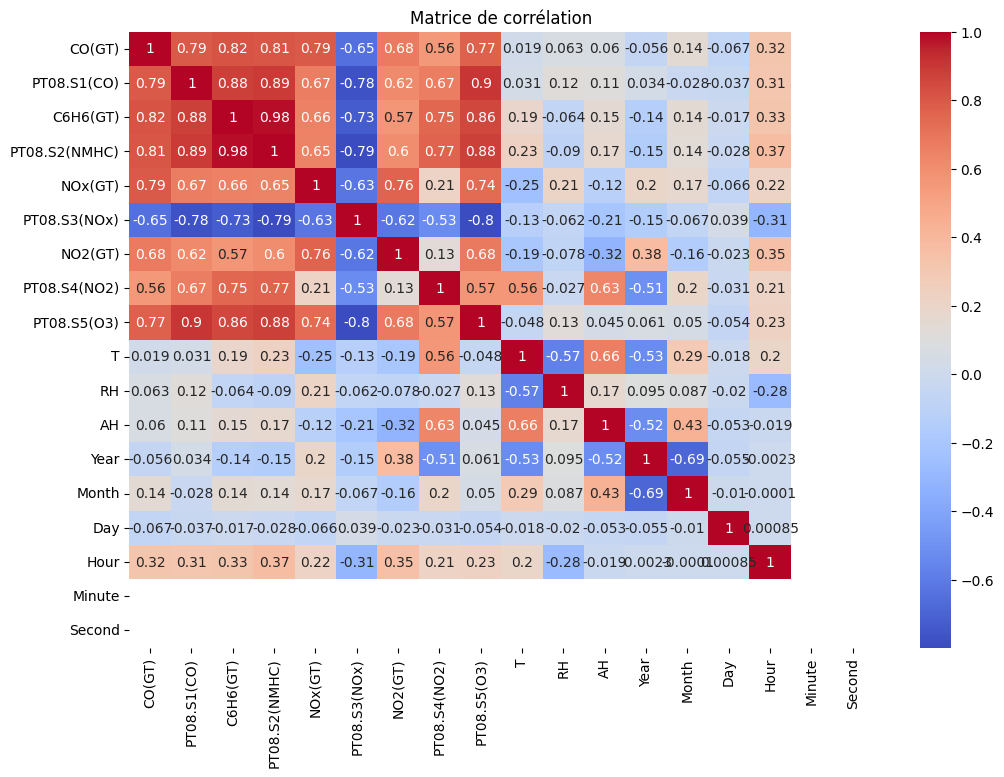

In [ ]:
#matrice de correlation


plt.figure(figsize=(12,8))
sns.heatmap(df[cols_numeriques].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
#separation du data

numerical_features = [
    "CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)", "NOx(GT)",
    "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH",
    "Year", "Month", "Day", "Hour", "Minute", "Second"
]

X = df[numerical_features]
y = df["C6H6(GT)"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7485, 17)
Test size: (1872, 17)


In [ ]:
#regression lineaire
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R² :", r2)
print("RMSE :", rmse)
print("MAE :", mae)

R² : 0.9848984074171206
RMSE : 0.12427801094108794
MAE : 0.08516275658868609


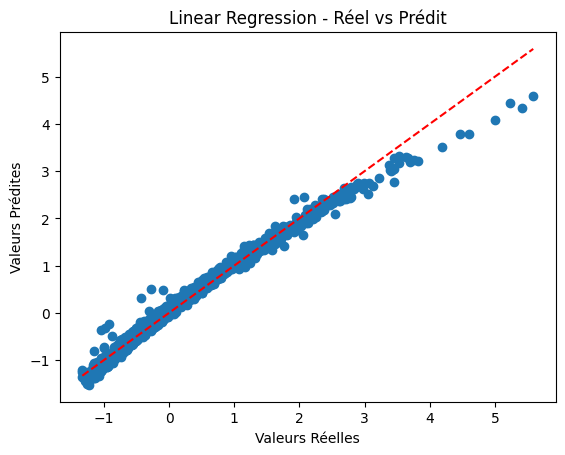

In [ ]:
#Scatter plot réel vs prédit
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonale
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("Linear Regression - Réel vs Prédit")
plt.show()

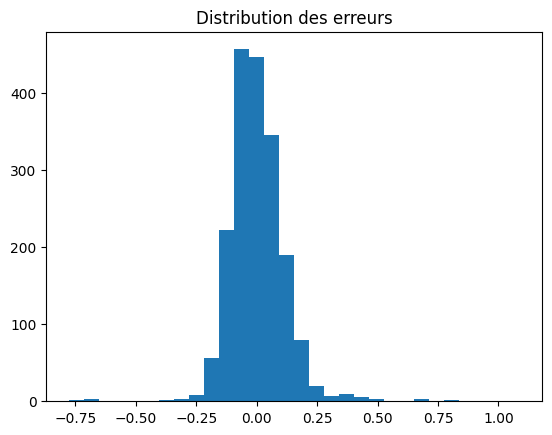

In [ ]:
#Histogramme des erreurs
errors = y_test - y_pred
plt.hist(errors, bins=30)
plt.title("Distribution des erreurs")
plt.show()

In [ ]:
#SVM
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Évaluation
r2 = r2_score(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae = mean_absolute_error(y_test, y_pred_svr)

print("SVR")
print("R² :", r2)
print("RMSE :", rmse)
print("MAE :", mae)



SVR
R² : 0.9950747404676507
RMSE : 0.07097370534243577
MAE : 0.041564085239367304


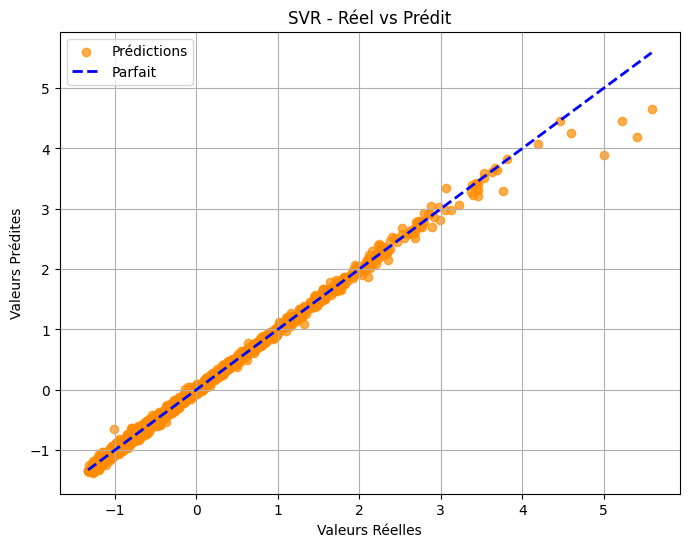

In [ ]:
# Courbe Réel vs Prédit
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_svr, color='darkorange', alpha=0.7, label='Prédictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'b--', lw=2, label='Parfait')
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("SVR - Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()



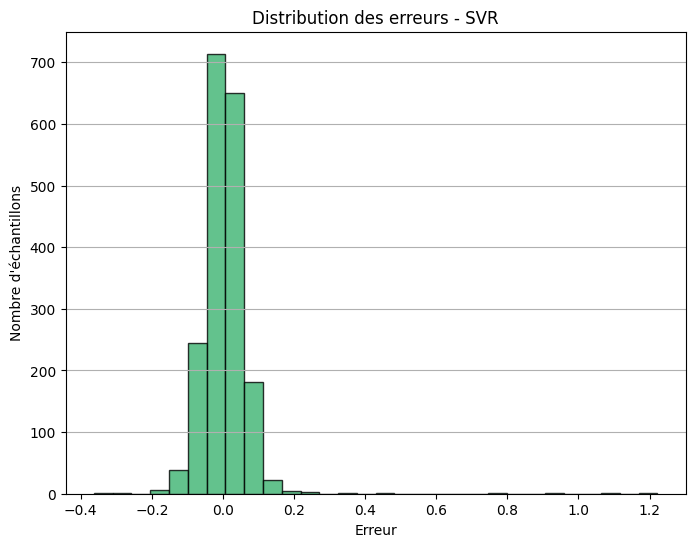

In [ ]:
# Histogramme des erreurs
errors = y_test - y_pred_svr
plt.figure(figsize=(8,6))
plt.hist(errors, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Distribution des erreurs - SVR")
plt.xlabel("Erreur")
plt.ylabel("Nombre d'échantillons")
plt.grid(axis='y')
plt.show()

In [ ]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Évaluation
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest")
print("R² :", r2)
print("RMSE :", rmse)
print("MAE :", mae)

Random Forest
R² : 0.9996708074898769
RMSE : 0.018348809499439837
MAE : 0.004725691567090778


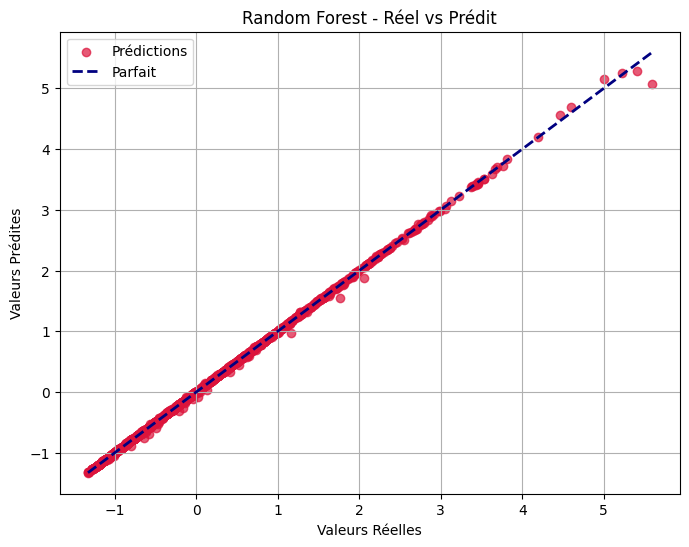

In [ ]:
# Courbe Réel vs Prédit
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, color='crimson', alpha=0.7, label='Prédictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'navy', lw=2, linestyle='--', label='Parfait')
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("Random Forest - Réel vs Prédit")
plt.legend()
plt.grid(True)
plt.show()

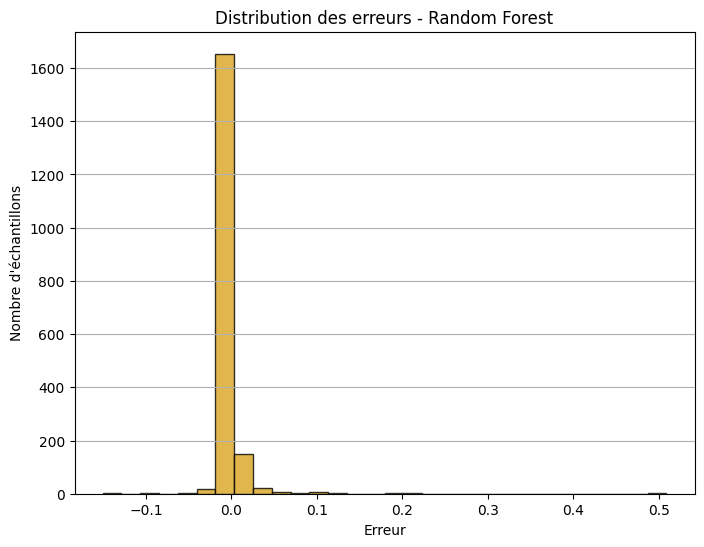

In [ ]:
# Histogramme des erreurs
errors = y_test - y_pred_rf
plt.figure(figsize=(8,6))
plt.hist(errors, bins=30, color='goldenrod', edgecolor='black', alpha=0.8)
plt.title("Distribution des erreurs - Random Forest")
plt.xlabel("Erreur")
plt.ylabel("Nombre d'échantillons")
plt.grid(axis='y')
plt.show()

In [ ]:
#comparaison entre les 3 models

# Fonction pour calculer métriques
def get_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# Calcul métriques
metrics = {
    "Linear Regression": get_metrics(y_test, y_pred_lr),
    "Random Forest": get_metrics(y_test, y_pred_rf),
    "SVR": get_metrics(y_test, y_pred_svr)
}

# Tableau DataFrame
metrics_df = pd.DataFrame(metrics, index=["R2", "RMSE", "MAE"]).T
print(metrics_df)

                         R2      RMSE       MAE
Linear Regression  0.984898  0.124278  0.085163
Random Forest      0.999671  0.018349  0.004726
SVR                0.995075  0.070974  0.041564


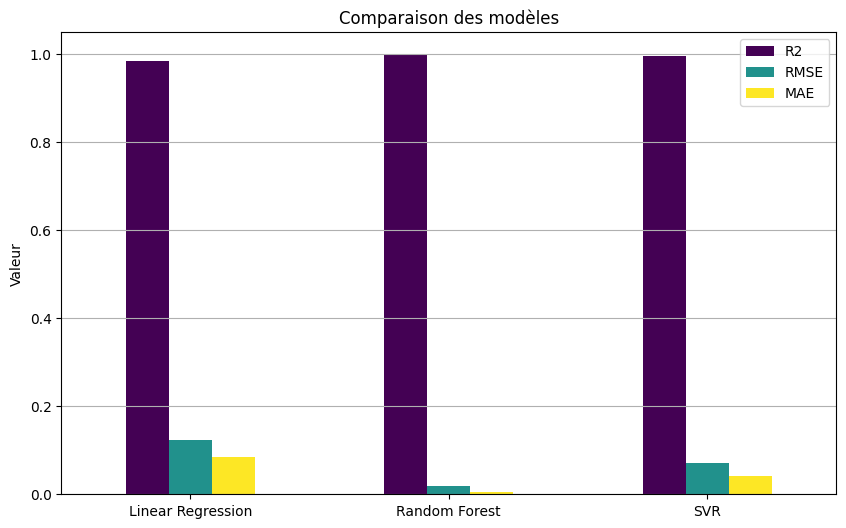

In [ ]:

metrics_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Comparaison des modèles")
plt.ylabel("Valeur")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

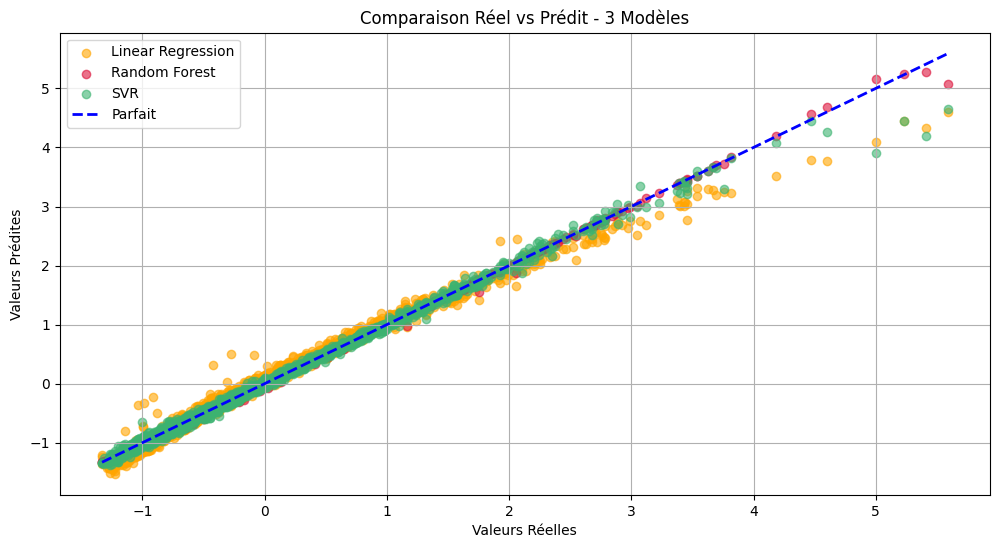

In [ ]:
#Scatter plots réel vs prédit pour les trois modèles
plt.figure(figsize=(12,6))

plt.scatter(y_test, y_pred_lr, color='orange', alpha=0.6, label='Linear Regression')
plt.scatter(y_test, y_pred_rf, color='crimson', alpha=0.6, label='Random Forest')
plt.scatter(y_test, y_pred_svr, color='mediumseagreen', alpha=0.6, label='SVR')

# Diagonale parfaite
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label='Parfait')

plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("Comparaison Réel vs Prédit - 3 Modèles")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Prédictions sur le jeu TRAIN
y_pred_lr_train = lr.predict(X_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_svr_train = svr.predict(X_train)

# 🔹 Calcul métriques
metrics_train = {
    "Linear Regression": get_metrics(y_train, y_pred_lr_train),
    "Random Forest": get_metrics(y_train, y_pred_rf_train),
    "SVR": get_metrics(y_train, y_pred_svr_train)
}

# 🔹 Tableau DataFrame
metrics_train_df = pd.DataFrame(metrics_train, index=["R2", "RMSE", "MAE"]).T
print(" Métriques sur le TRAIN set")
print(metrics_train_df)

 Métriques sur le TRAIN set
                         R2      RMSE       MAE
Linear Regression  0.983800  0.126918  0.084933
Random Forest      0.999911  0.009417  0.001756
SVR                0.995558  0.066460  0.040157


In [ ]:
import time

# Dictionnaire pour stocker les temps
temps_modeles = {
    "Modèle": [],
    "Temps entraînement (sec)": [],
    "Temps prédiction (sec)": []
}

# Linear Regression
temps_modeles["Modèle"].append("Linear Regression")

# Temps entraînement
start_train = time.time()
lr.fit(X_train, y_train)
end_train = time.time()
temps_train = end_train - start_train
temps_modeles["Temps entraînement (sec)"].append(temps_train)

# Temps prédiction
start_pred = time.time()
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)
end_pred = time.time()
temps_pred = end_pred - start_pred
temps_modeles["Temps prédiction (sec)"].append(temps_pred)

# Random Forest
temps_modeles["Modèle"].append("Random Forest")

start_train = time.time()
rf.fit(X_train, y_train)
end_train = time.time()
temps_modeles["Temps entraînement (sec)"].append(end_train - start_train)

start_pred = time.time()
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)
end_pred = time.time()
temps_modeles["Temps prédiction (sec)"].append(end_pred - start_pred)

# SVR
temps_modeles["Modèle"].append("SVR")

start_train = time.time()
svr.fit(X_train, y_train)
end_train = time.time()
temps_modeles["Temps entraînement (sec)"].append(end_train - start_train)

start_pred = time.time()
y_pred_svr_train = svr.predict(X_train)
y_pred_svr_test = svr.predict(X_test)
end_pred = time.time()
temps_modeles["Temps prédiction (sec)"].append(end_pred - start_pred)

# Tableau résumé
temps_df = pd.DataFrame(temps_modeles)
print(temps_df)

              Modèle  Temps entraînement (sec)  Temps prédiction (sec)
0  Linear Regression                  0.008274                0.004939
1      Random Forest                  7.748564                0.143047
2                SVR                  0.268746                0.211227


Classification du Gaz C6H6

In [ ]:
#classification high low du gaz c6h6

# seuil = médiane
threshold = df["C6H6(GT)"].median()

# créer cible binaire : 0 = low, 1 = high
df["C6H6_class"] = (df["C6H6(GT)"] > threshold).astype(int)

print(df["C6H6_class"].value_counts())

C6H6_class
0    4710
1    4647
Name: count, dtype: int64


In [ ]:
# On prend les mêmes features numériques que pour la régression
X_class = X  # déjà préparé avant .
y_class = df["C6H6_class"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Modèle
nb = GaussianNB()

#  Entraînement
nb.fit(X_train_cls, y_train_cls)

#  Prédictions
y_pred_train = nb.predict(X_train_cls)
y_pred_test = nb.predict(X_test_cls)
y_prob_test = nb.predict_proba(X_test_cls)[:,1]  # pour ROC



 Naive Bayes - TRAIN
              precision    recall  f1-score   support

           0       0.90      0.95      0.93      3768
           1       0.95      0.90      0.92      3717

    accuracy                           0.92      7485
   macro avg       0.92      0.92      0.92      7485
weighted avg       0.92      0.92      0.92      7485

Naive Bayes - TEST
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       942
           1       0.94      0.88      0.91       930

    accuracy                           0.91      1872
   macro avg       0.91      0.91      0.91      1872
weighted avg       0.91      0.91      0.91      1872



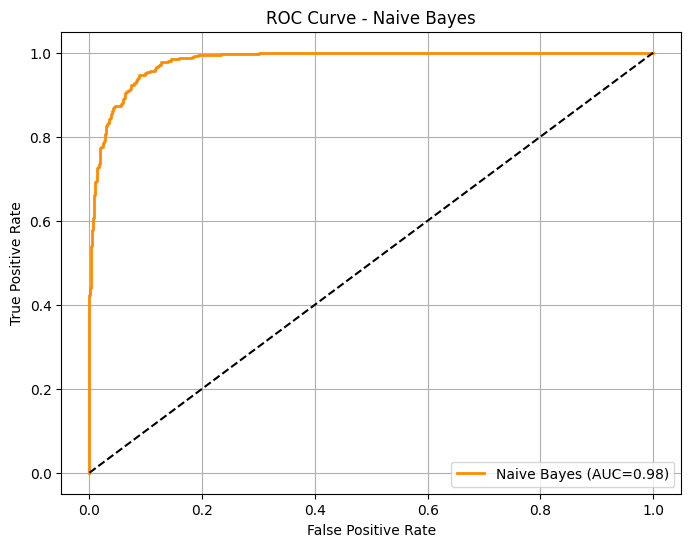

In [ ]:
#  Rapports
print(" Naive Bayes - TRAIN")
print(classification_report(y_train_cls, y_pred_train))

print("Naive Bayes - TEST")
print(classification_report(y_test_cls, y_pred_test))

#  ROC curve
fpr, tpr, _ = roc_curve(y_test_cls, y_prob_test)
auc = roc_auc_score(y_test_cls, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Naive Bayes (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.grid(True)
plt.show()

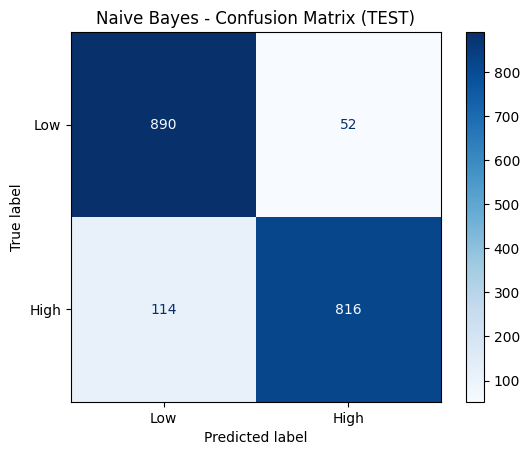

In [ ]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_cls, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Naive Bayes - Confusion Matrix (TEST)")
plt.show()


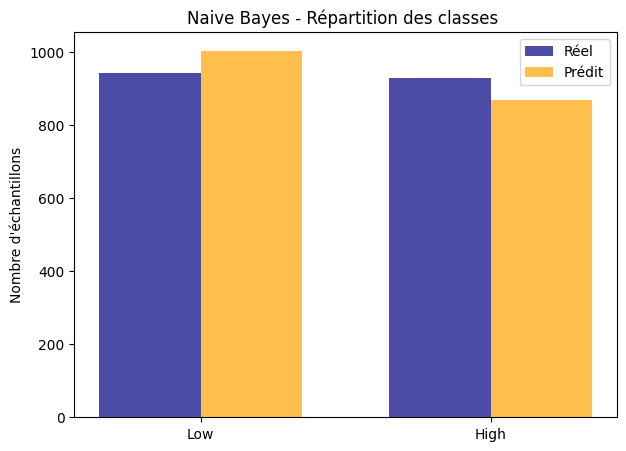

In [ ]:
# Histogramme des classes prédites vs réelles
classes = ["Low", "High"]
counts_true = [np.sum(y_test_cls==0), np.sum(y_test_cls==1)]
counts_pred = [np.sum(y_pred_test==0), np.sum(y_pred_test==1)]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, counts_true, width, label="Réel", color="navy", alpha=0.7)
plt.bar(x + width/2, counts_pred, width, label="Prédit", color="orange", alpha=0.7)
plt.xticks(x, classes)
plt.ylabel("Nombre d'échantillons")
plt.title("Naive Bayes - Répartition des classes ")
plt.legend()
plt.show()

SVM

 SVM - TRAIN
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3768
           1       0.99      0.98      0.98      3717

    accuracy                           0.98      7485
   macro avg       0.98      0.98      0.98      7485
weighted avg       0.98      0.98      0.98      7485

 SVM - TEST
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       942
           1       0.98      0.97      0.98       930

    accuracy                           0.98      1872
   macro avg       0.98      0.98      0.98      1872
weighted avg       0.98      0.98      0.98      1872



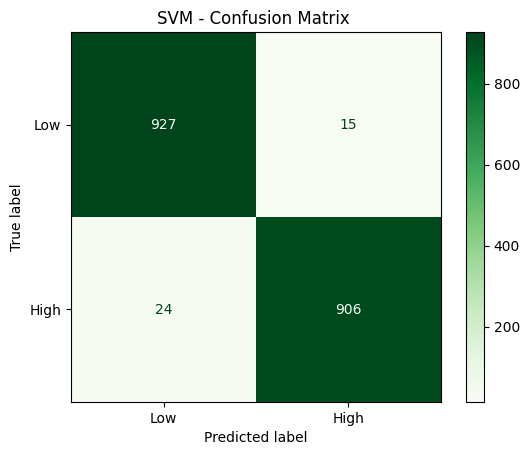

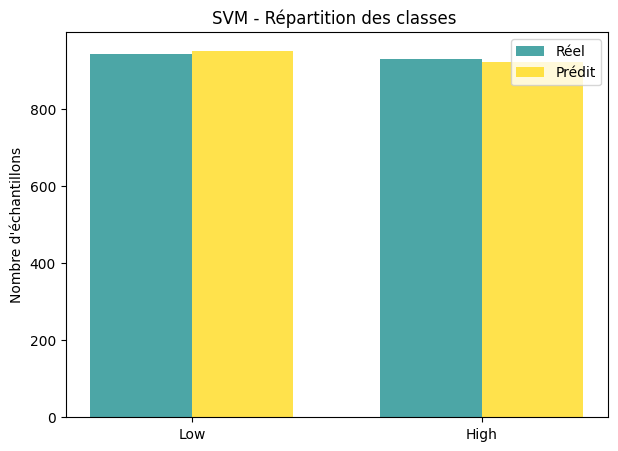

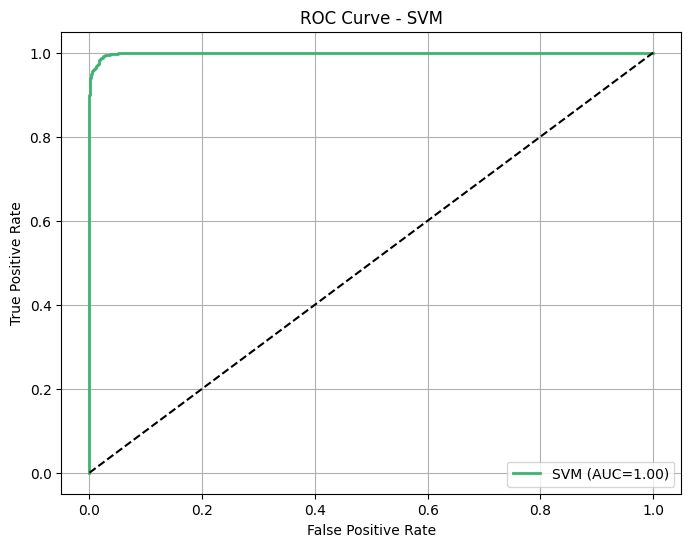

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#  Entraînement
svm_cls = SVC(probability=True, random_state=42)
svm_cls.fit(X_train_cls, y_train_cls)

#  Prédictions
y_pred_train = svm_cls.predict(X_train_cls)
y_pred_test = svm_cls.predict(X_test_cls)
y_prob_test = svm_cls.predict_proba(X_test_cls)[:,1]  # pour ROC

#  Rapports
print(" SVM - TRAIN")
print(classification_report(y_train_cls, y_pred_train))

print(" SVM - TEST")
print(classification_report(y_test_cls, y_pred_test))

#  Matrice de confusion graphique
cm = confusion_matrix(y_test_cls, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Greens)
plt.title("SVM - Confusion Matrix ")
plt.show()

#  Histogramme des classes prédites vs réelles
classes = ["Low", "High"]
counts_true = [np.sum(y_test_cls==0), np.sum(y_test_cls==1)]
counts_pred = [np.sum(y_pred_test==0), np.sum(y_pred_test==1)]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, counts_true, width, label="Réel", color="teal", alpha=0.7)
plt.bar(x + width/2, counts_pred, width, label="Prédit", color="gold", alpha=0.7)
plt.xticks(x, classes)
plt.ylabel("Nombre d'échantillons")
plt.title("SVM - Répartition des classes ")
plt.legend()
plt.show()

#  ROC curve
fpr, tpr, _ = roc_curve(y_test_cls, y_prob_test)
auc = roc_auc_score(y_test_cls, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='mediumseagreen', lw=2, label=f'SVM (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid(True)
plt.show()

 KNN - TRAIN
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3768
           1       0.98      0.96      0.97      3717

    accuracy                           0.97      7485
   macro avg       0.97      0.97      0.97      7485
weighted avg       0.97      0.97      0.97      7485

 KNN - TEST
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       942
           1       0.97      0.95      0.96       930

    accuracy                           0.96      1872
   macro avg       0.96      0.96      0.96      1872
weighted avg       0.96      0.96      0.96      1872



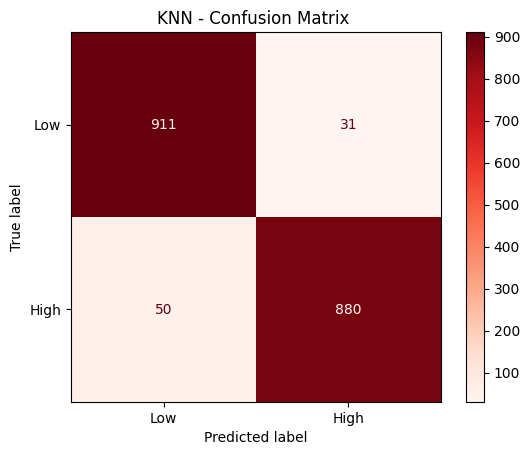

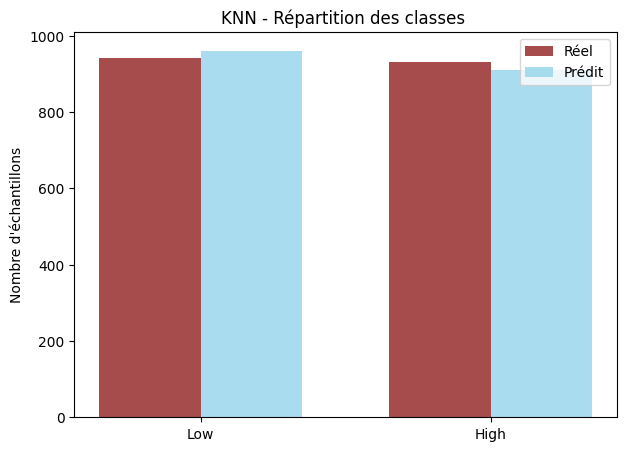

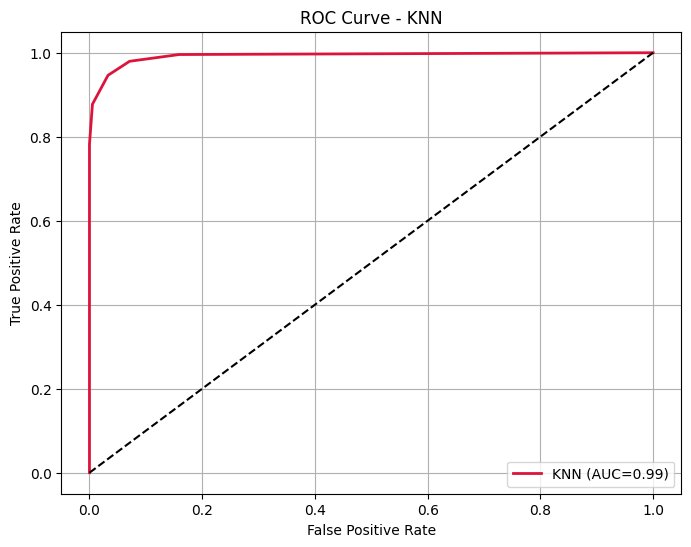

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#  Entraînement
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_cls, y_train_cls)

#  Prédictions
y_pred_train = knn.predict(X_train_cls)
y_pred_test = knn.predict(X_test_cls)
y_prob_test = knn.predict_proba(X_test_cls)[:,1]  # pour ROC

#  Rapports
print(" KNN - TRAIN")
print(classification_report(y_train_cls, y_pred_train))

print(" KNN - TEST")
print(classification_report(y_test_cls, y_pred_test))

#  Matrice de confusion graphique
cm = confusion_matrix(y_test_cls, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Reds)
plt.title("KNN - Confusion Matrix ")
plt.show()

#  Histogramme des classes prédites vs réelles
classes = ["Low", "High"]
counts_true = [np.sum(y_test_cls==0), np.sum(y_test_cls==1)]
counts_pred = [np.sum(y_pred_test==0), np.sum(y_pred_test==1)]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, counts_true, width, label="Réel", color="maroon", alpha=0.7)
plt.bar(x + width/2, counts_pred, width, label="Prédit", color="skyblue", alpha=0.7)
plt.xticks(x, classes)
plt.ylabel("Nombre d'échantillons")
plt.title("KNN - Répartition des classes ")
plt.legend()
plt.show()

#  ROC curve
fpr, tpr, _ = roc_curve(y_test_cls, y_prob_test)
auc = roc_auc_score(y_test_cls, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'KNN (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#  Modèle
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_cls, y_train_cls)

#  Prédictions
y_pred_train = dtree.predict(X_train_cls)
y_pred_test = dtree.predict(X_test_cls)
y_prob_test = dtree.predict_proba(X_test_cls)[:,1]  # pour ROC

#  Rapports
print ("Decision Tree - TRAIN")
print(classification_report(y_train_cls, y_pred_train))

print(" Decision Tree - TEST")
print(classification_report(y_test_cls, y_pred_test))

Decision Tree - TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3768
           1       1.00      1.00      1.00      3717

    accuracy                           1.00      7485
   macro avg       1.00      1.00      1.00      7485
weighted avg       1.00      1.00      1.00      7485

 Decision Tree - TEST
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       942
           1       0.99      1.00      1.00       930

    accuracy                           1.00      1872
   macro avg       1.00      1.00      1.00      1872
weighted avg       1.00      1.00      1.00      1872



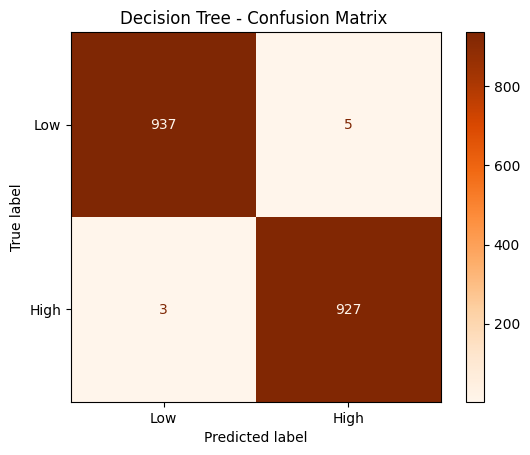

In [ ]:
#matrice de Confusion
cm = confusion_matrix(y_test_cls, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Oranges)
plt.title("Decision Tree - Confusion Matrix ")
plt.show()

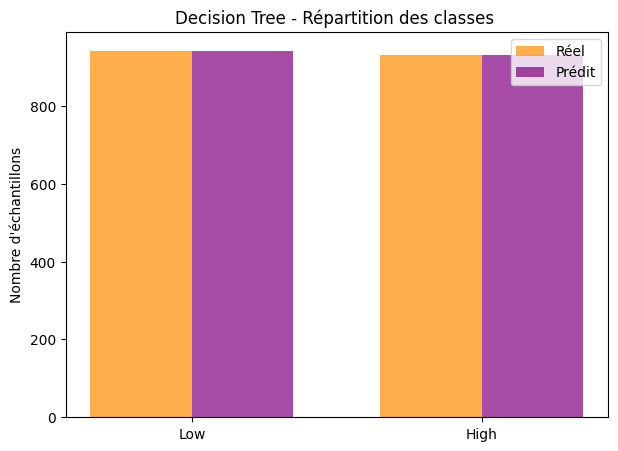

In [ ]:
#Histogramme classes prédites vs réelles
classes = ["Low", "High"]
counts_true = [np.sum(y_test_cls==0), np.sum(y_test_cls==1)]
counts_pred = [np.sum(y_pred_test==0), np.sum(y_pred_test==1)]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, counts_true, width, label="Réel", color="darkorange", alpha=0.7)
plt.bar(x + width/2, counts_pred, width, label="Prédit", color="purple", alpha=0.7)
plt.xticks(x, classes)
plt.ylabel("Nombre d'échantillons")
plt.title("Decision Tree - Répartition des classes ")
plt.legend()
plt.show()

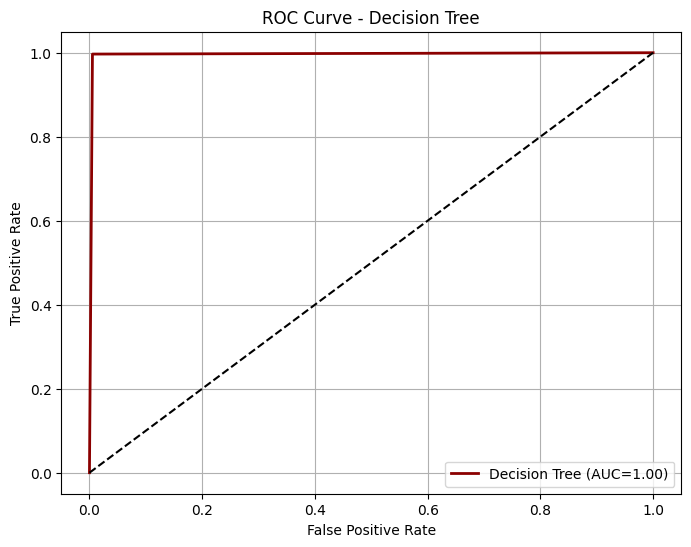

In [ ]:
#ROC curve + AUC
fpr, tpr, _ = roc_curve(y_test_cls, y_prob_test)
auc = roc_auc_score(y_test_cls, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Decision Tree (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Réduction PCA en 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cls)
X_test_pca = pca.transform(X_test_cls)

# Ré-entrainement du modèle sur PCA pour visualisation
dtree_pca = DecisionTreeClassifier(random_state=42)
dtree_pca.fit(X_train_pca, y_train_cls)

DecisionTreeClassifier(random_state=42)

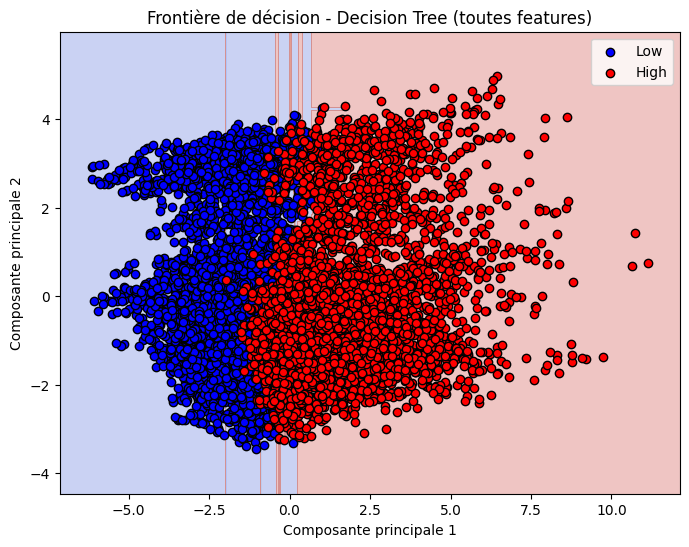

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

#  Entraîner le modèle sur toutes les features
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_cls, y_train_cls)  # Toutes les features utilisées ici

#  Réduction PCA pour visualiser
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cls)
X_test_pca = pca.transform(X_test_cls)

# Ré-entrainement juste pour tracer la frontière sur PCA
dtree_pca = DecisionTreeClassifier(random_state=42)
dtree_pca.fit(X_train_pca, y_train_cls)

#  Créer la grille pour la visualisation
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = dtree_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#  Tracer la frontière
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_pca[y_train_cls==0,0], X_train_pca[y_train_cls==0,1], c='blue', label='Low', edgecolor='k')
plt.scatter(X_train_pca[y_train_cls==1,0], X_train_pca[y_train_cls==1,1], c='red', label='High', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Decision Tree (toutes features)")
plt.legend()
plt.show()

In [ ]:
q1 = df["C6H6(GT)"].quantile(0.33)
q2 = df["C6H6(GT)"].quantile(0.66)

def c6h6_multiclass(val):
    if val <= q1:
        return 0  # Low
    elif val <= q2:
        return 1  # Medium
    else:
        return 2  # High

df["C6H6_class3"] = df["C6H6(GT)"].apply(c6h6_multiclass)
y_class = df["C6H6_class3"].astype(int)  # forcer le type int

In [ ]:
numerical_features = [ "CO(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)",
                      "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)",
                       "PT08.S5(O3)", "T", "RH", "AH", "Year", "Month", "Day", "Hour", "Minute", "Second" ]
X_class_numeric = df[numerical_features]
y_class = df["C6H6_class3"].astype(int)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_class_numeric, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

SVC(probability=True, random_state=42)

 SVM - TRAIN
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2475
           1       0.96      0.96      0.96      2488
           2       0.98      0.98      0.98      2522

    accuracy                           0.97      7485
   macro avg       0.97      0.97      0.97      7485
weighted avg       0.97      0.97      0.97      7485

 SVM - TEST
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       619
           1       0.94      0.93      0.94       622
           2       0.97      0.97      0.97       631

    accuracy                           0.96      1872
   macro avg       0.96      0.96      0.96      1872
weighted avg       0.96      0.96      0.96      1872



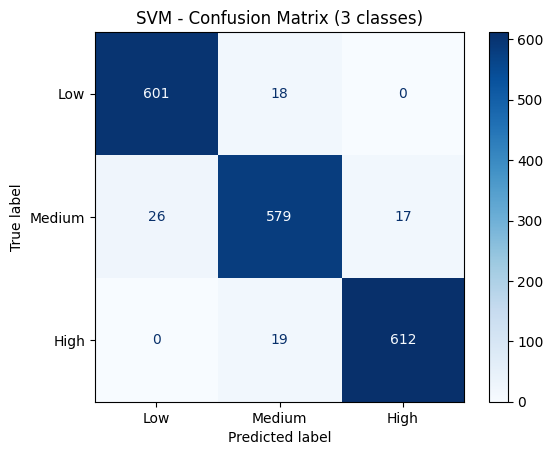

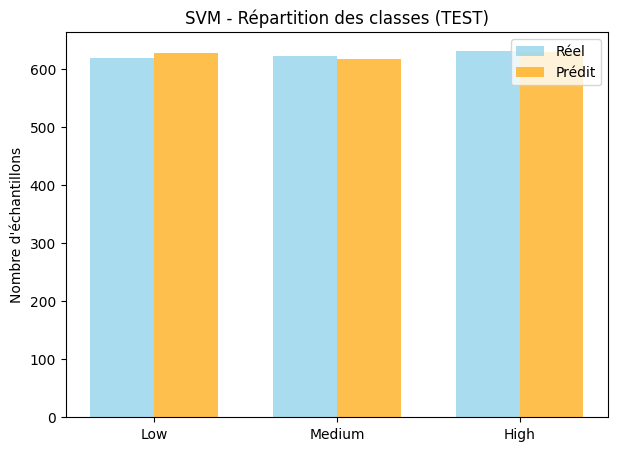

In [ ]:


#  Prédictions -
y_pred_train = svm.predict(X_train)
y_pred_test = svm.predict(X_test)
y_prob_test = svm.predict_proba(X_test)

#  Classification report -
print(" SVM - TRAIN")
print(classification_report(y_train, y_pred_train))

print(" SVM - TEST")
print(classification_report(y_test, y_pred_test))

#  Matrice de confusion -
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","Medium","High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM - Confusion Matrix (3 classes)")
plt.show()

#  Histogramme classes réelles vs prédites -
classes = ["Low","Medium","High"]
counts_true = [np.sum(y_test==0), np.sum(y_test==1), np.sum(y_test==2)]
counts_pred = [np.sum(y_pred_test==0), np.sum(y_pred_test==1), np.sum(y_pred_test==2)]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, counts_true, width, label="Réel", color="skyblue", alpha=0.7)
plt.bar(x + width/2, counts_pred, width, label="Prédit", color="orange", alpha=0.7)
plt.xticks(x, classes)
plt.ylabel("Nombre d'échantillons")
plt.title("SVM - Répartition des classes (TEST)")
plt.legend()
plt.show()




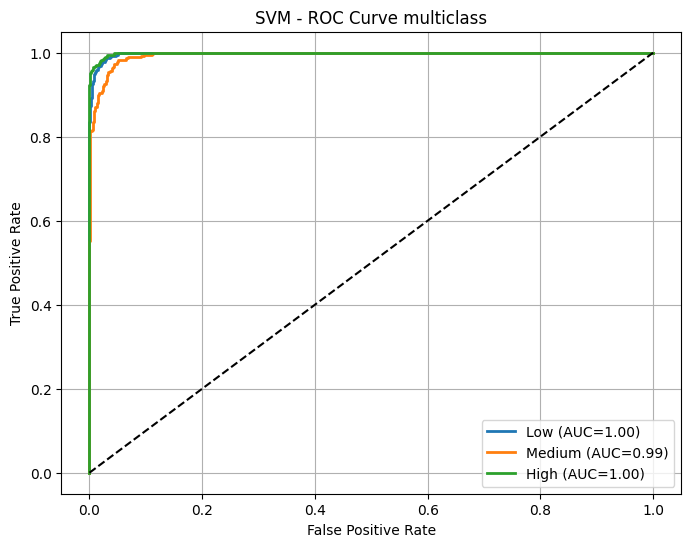

In [ ]:
from sklearn.preprocessing import label_binarize
#  ROC curve multiclass
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_test[:,i])
    auc = roc_auc_score(y_test_bin[:,i], y_prob_test[:,i])
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM - ROC Curve multiclass")
plt.legend()
plt.grid(True)
plt.show()



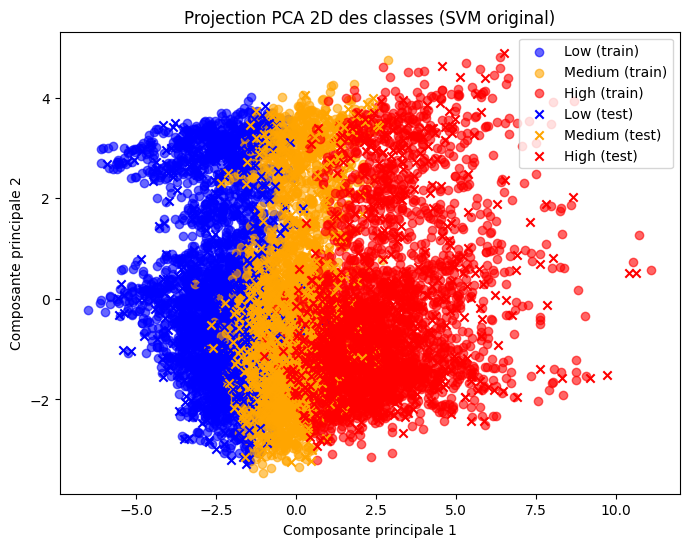

In [ ]:
from sklearn.decomposition import PCA

# PCA 2D juste pour visualiser la répartition des classes
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], c='blue', label='Low (train)', marker='o', alpha=0.6)
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], c='orange', label='Medium (train)', marker='o', alpha=0.6)
plt.scatter(X_train_pca[y_train==2,0], X_train_pca[y_train==2,1], c='red', label='High (train)', marker='o', alpha=0.6)

plt.scatter(X_test_pca[y_test==0,0], X_test_pca[y_test==0,1], c='blue', marker='x', label='Low (test)')
plt.scatter(X_test_pca[y_test==1,0], X_test_pca[y_test==1,1], c='orange', marker='x', label='Medium (test)')
plt.scatter(X_test_pca[y_test==2,0], X_test_pca[y_test==2,1], c='red', marker='x', label='High (test)')

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA 2D des classes (SVM original)")
plt.legend()
plt.show()